### `etd-rk3.ipynb`
*Created: June 15, 2026*

This notebook implements the `ETD-RK3` method, a third-order exponential time differencing (ETD) method for solving systems of differential equations of the form $\frac{du}{dt} = Au + N(u,t)$, where $A$ is an $N \times N$ constant matrix and $N$ is a nonlinear function. 

In [1]:
@time using OrdinaryDiffEq, CairoMakie, LinearAlgebra, LaTeXStrings, Printf, NBInclude, Statistics, UnPack

 59.212471 seconds (8.39 M allocations: 509.098 MiB, 2.62% gc time, 0.75% compilation time: 49% of which was recompilation)


In [2]:
@nbinclude("../set_makie_defaults.ipynb")
@nbinclude("phi_functions.ipynb")

In [3]:
function etd_rk3(A, f; u0, tspan, Δt, p = nothing)
    """
    Solves the ODE system du/dt = Au + f(u,p,t), u(0) = u0 for t ∈ [tspan[1], tspan[2]]. 
    
    PARAMETERS
    ----------
    A :: N x N constant matrix (a scalar if N = 1)
    f :: Nonlinear function from R^N to R^N 
    u0 :: The initial condition (a vector of length N, or a scalar) 
    tspan :: The time interval over which to integrate the ODE. 
    Δt :: The time step (fixed)
    p :: Parameter for the nonlinear term `f` (if required) 
    
    RETURNS
    -------
    sol : Tuple 
        sol.u  :: the 
        sol.t  :: 
        sol.Δt ::
    
    """

    ################  INPUT VALIDATION ######################

    #If A is a scalar, u0 must be a scalar.  If A is a matrix, u0 must be a vector. 
    (A isa AbstractMatrix && u0 isa AbstractVector) || (A isa Number && u0 isa Number) || 
    throw(ArgumentError("Types of A and u0 are incompatible: typeof(A) = $(typeof(A)), typeof(u0) = $(typeof(u0))"))

    #If A is a matrix, it must be square and u0 must have compatible size 
    if A isa AbstractMatrix
        size(A, 1) == size(A, 2) || throw(ArgumentError("A must be a square matrix. Passed A with size $(size(A))"))
        size(A, 1) == length(u0) || throw(ArgumentError("Must have size(A,1) == size(A,2) = length(u0)." ))        
    end 

    tspan[1] < tspan[2] || throw(ArgumentError("t0 must be smaller than tf. Passed t0 = $(tspan[1]), tf = $(tspan[2])."))

    ################  TYPE CONVERSION ##########################
   
    #Get the eltype (if array) or type (if scalar) of A and u0
    A_type = A isa AbstractMatrix ? eltype(A) : typeof(A)
    u0_type = u0 isa AbstractVector ? eltype(u0) : typeof(u0) 

    T = promote_type(A_type, u0_type, Float64)       
    A = A isa AbstractMatrix ? Matrix{T}(A) : T(A)
    u0 = u0 isa AbstractVector ? Vector{T}(u0) : T(u0)
    
    ############################################################

    t0, tf = tspan 
    nsteps = Int(floor((tf - t0) / Δt))                      #Number of time steps 
    t = collect(range(t0, step = Δt, length = nsteps + 1))   #Times at which to record solution 

    u = [zero(u0) for _ in 1:nsteps+1]    #Vector to store solution iterates 
    u[1] = u0 

    #Compute some matrices

    Z = Δt*A
    Z_half = (Δt/2)*A 
    
    Φ₀, Φ₁, Φ₂, Φ₃ = phis(Z, 3)          #ϕ_0(Δt*A), ϕ_1(Δt*A), ϕ_2(Δt*A), ϕ_3(Δt*A)
    Φ₀_half, Φ₁_half = phis(Z_half, 1)   #ϕ_0(Δt*A/2), ϕ_1(Δt*A/2) 
    
    B₁ = Φ₁ - 3*Φ₂ + 4*Φ₃
    B₂ = 4*Φ₂ - 8*Φ₃
    B₃ = -Φ₂ + 4*Φ₃
    
    for n = 1:nsteps   #n+1 = 2,...nsteps + 1 
        
        N₁ = f(u[n], p, t[n])
        aₙ = Φ₀_half * u[n]  +  (Δt/2) * Φ₁_half * N₁
        
        N₂ = f(aₙ, p, t[n] + Δt/2)
        bₙ = Φ₀ * u[n]       +  Δt * Φ₁ * (2*N₂ - N₁)
        
        N₃ = f(bₙ, p, t[n] + Δt)

        u[n+1] = Φ₀*u[n] + Δt * (B₁*N₁ + B₂*N₂ + B₃*N₃) 

    end 
   
    return (u = u, t = t, Δt = Δt, p = p) 
end 

etd_rk3 (generic function with 1 method)

In [4]:
#Test ETD Euler using a *scalar* equation
function u_exact(t,p)
    @unpack a, u0 = p 
    return a ./ (1.0 - (1.0 - a/u0)*exp(a*t))
end 

a = 3.0 
u0 = 1.0
p = (a = a, u0 = u0)
f(u,p,t) = u^2 
sol = etd_rk3(-a, f, u0 = 1.0; Δt = 0.01, tspan = (0,3.0), p = p);

In [5]:
function plot_sol_1D(u_num::Vector{T}, t::Vector{T}; u_ex::Union{Vector{T},Nothing} = nothing, size = (400,400), 
                     title = "", markersize = 4, linewidth = 4, legend_pos = :rt) where T 

    fig = Figure(size = size)

    #Create plot 
    ax = Axis(fig[1,1], xlabel = L"t", ylabel = L"u", limits = (t[1], t[end], minimum(u_num), maximum(u_num)), title = title)

    #Plot exact solution (if given) 
    if u_ex != nothing
        lines!(ax, t, u_ex, linewidth = linewidth, color = :blue, label = "exact")
    end 

    #Plot numerical solution 
    scatter!(ax, t, u_num, markersize = markersize, color = :orange, label = "numerical")

    #Add legend 
    axislegend(ax, position = legend_pos)
    
    display(fig)
end 

plot_sol_1D (generic function with 1 method)

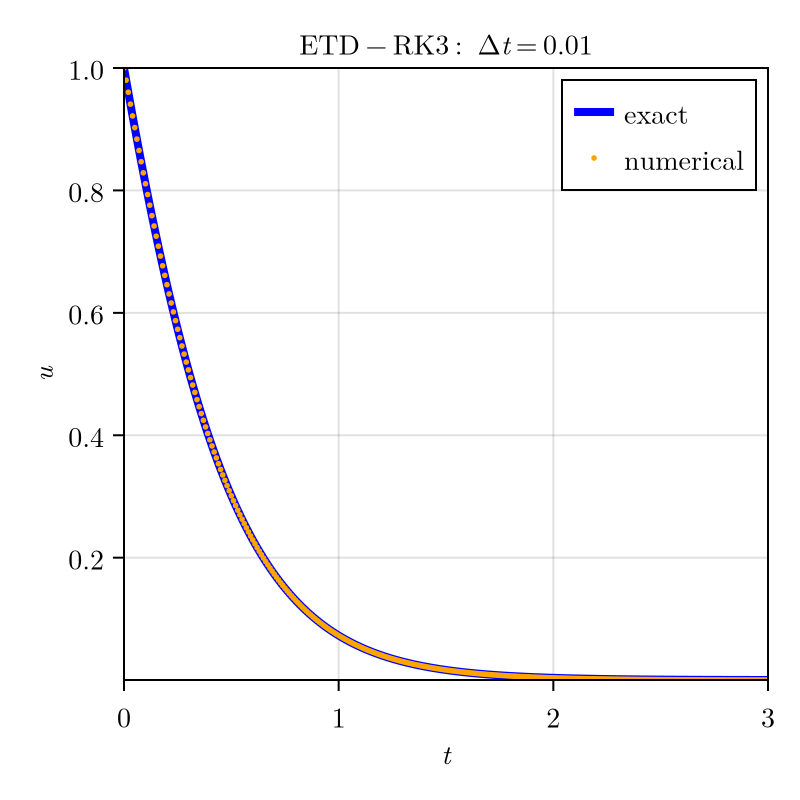

CairoMakie.Screen{IMAGE}


In [14]:
plot_sol_1D(sol.u, sol.t; u_ex = u_exact.(sol.t, Ref(p)), size = (400,400), title = L"\textrm{ETD-RK3: } Δt = %$(sol.Δt)")

In [7]:
#TESTING OUT ETD-RK2 using a system of 2 equations 
A = [-100.0 0.0; 0.0 -1.0]
u0 = [0.0, 1.0]

function f(u,p,t)
    f1 = cos(t) + 100*sin(t) + (u[1])^2 - (sin(t))^2 
    f2 = -sin(t) + cos(t) + u[1] * u[2] - sin(t) * cos(t)
    return [f1, f2]
end 

u_exact(t) = [sin(t), cos(t)]

@time out = etd_rk3(A, f, u0; tspan = (0, 3.0), Δt = 0.05, p = 1);

LoadError: MethodError: no method matching etd_rk3(::Matrix{Float64}, ::typeof(f), ::Vector{Float64}; tspan::Tuple{Int64, Float64}, Δt::Float64, p::Int64)
The function `etd_rk3` exists, but no method is defined for this combination of argument types.

[0mClosest candidates are:
[0m  etd_rk3(::Any, ::Any; u0, tspan, Δt, p)
[0m[90m   @[39m [35mMain[39m [90m[4mIn[3]:1[24m[39m


In [8]:
sol = out.u
t = out.t
Δt = out.Δt

u_num = getindex.(sol,1)
v_num = getindex.(sol,2)

ex_sol = u_exact.(t)
u_ex = getindex.(ex_sol, 1)
v_ex = getindex.(ex_sol, 2);

@printf("RMSE_u = %.4e\n", mean(sqrt.((u_ex .- u_num).^2))) 
@printf("RMSE_v = %.4e\n", mean(sqrt.((v_ex .- v_num).^2))) 
 
fig = Figure(size = (600,400))

Δt_str = @sprintf("%.2f", Δt)
ax = Axis(fig[1,1], xlabel = L"t", title = L"\textrm{ETD RK3:} Δt = %$(Δt_str)")
lines!(ax, t, u_ex, color = :blue, linewidth = 2, label = L"u \textrm{ exact}")
lines!(ax, t, v_ex, color = :orange, linewidth = 2, label = L"v \textrm{ exact}")

scatter!(ax, t, u_num, color = :purple, markersize = 4, label = L"u \textrm{ numerical}")
scatter!(ax, t, v_num, color = :red, markersize = 4, label = L"v \textrm{ numerical}")

Legend(fig[1,2], ax)
#axislegend(ax, position = :rt)
display(fig)

LoadError: UndefVarError: `out` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

In [157]:
#A = collect(reshape(1:4, 2, 2))

#A = rand(3,3)

f(u,p,t) = u.^2
u0 = [1.0, 1.0, 2.0]
A = 3.0
#u0 = 1.0

etd_rk3(A, f, u0; tspan = (0,1), Δt = 0.1)

In [161]:
1 isa AbstractArray

false

In [159]:
rand(3,2) isa AbstractArray

true

In [113]:
supertypeof(Float64)

LoadError: UndefVarError: `supertypeof` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

In [39]:
Matrix{Float64}(undef, (3,3))

3×3 Matrix{Float64}:
 0.0       1.0e-323  0.0
 3.0e-323  1.5e-323  0.0
 2.0e-323  4.4e-323  6.95233e-310